<ipython-input-6-2e82f32b20ec>:9: DtypeWarning: Columns (0: search_conducted) have mixed types. Specify dtype option on import or set low_memory=False.
  main_df = pd.read_csv(DATA_DIR / "df_with_dummy_final.csv")


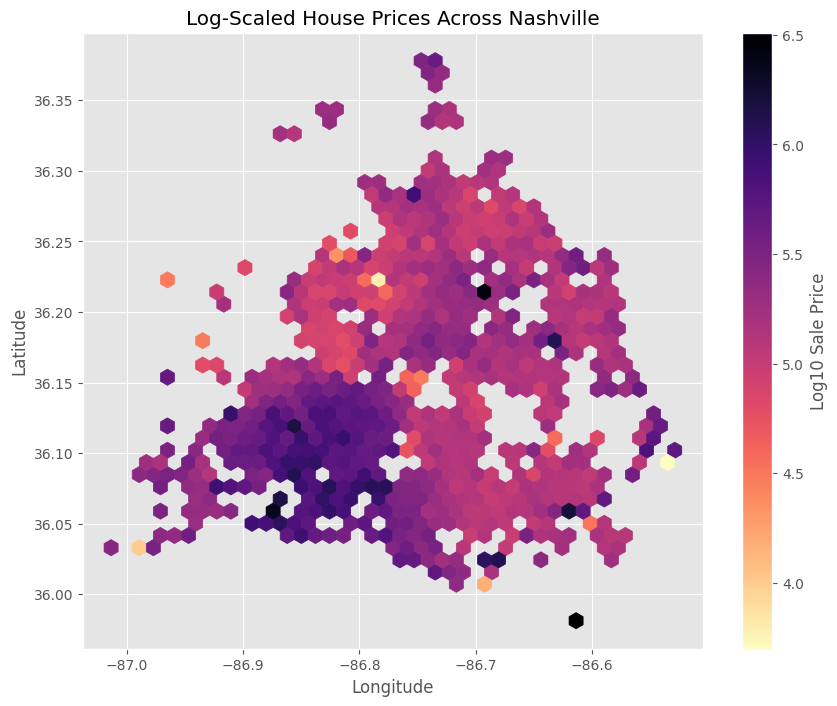

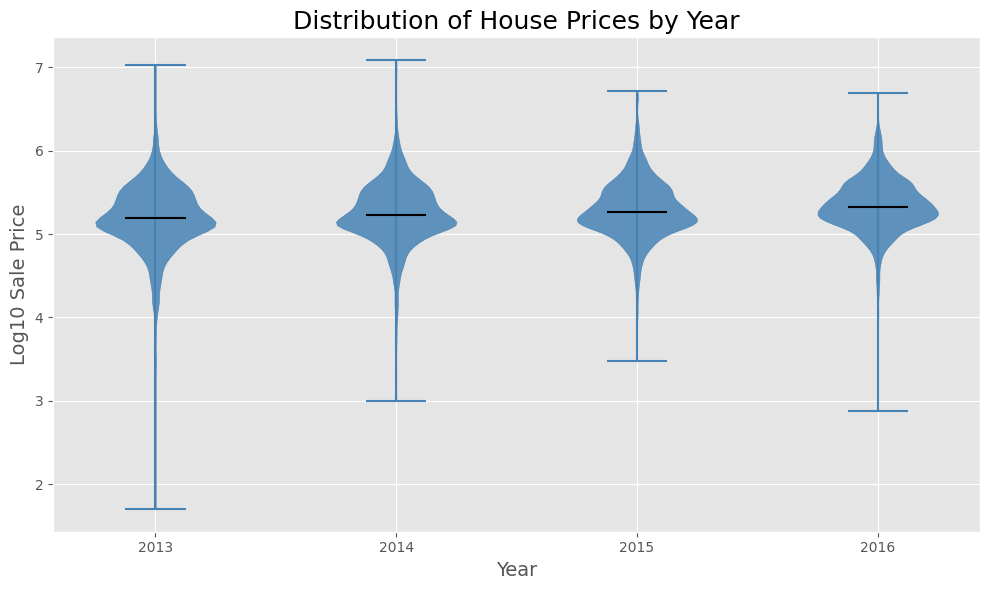

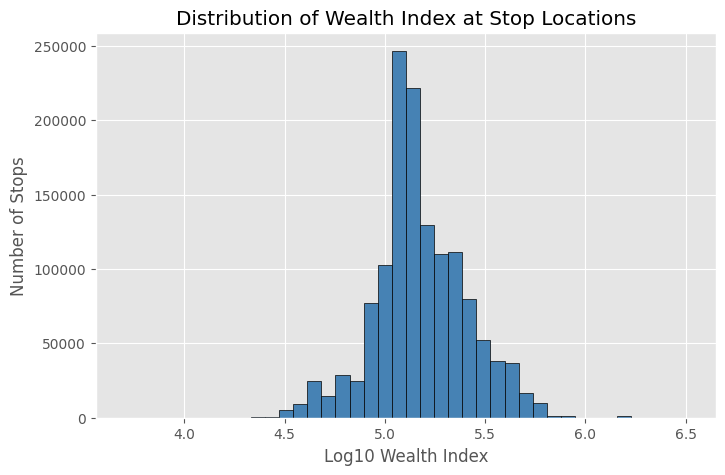

<Figure size 1000x600 with 0 Axes>

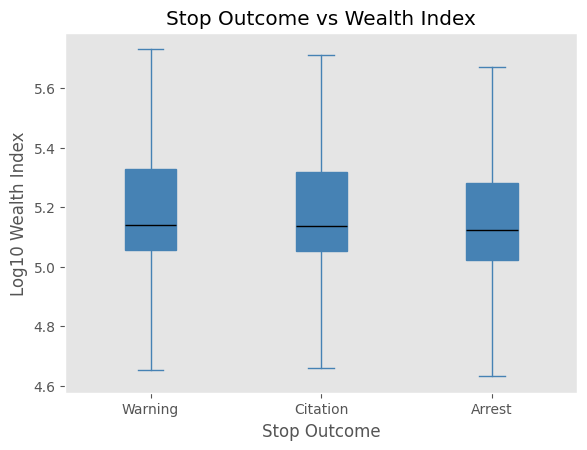

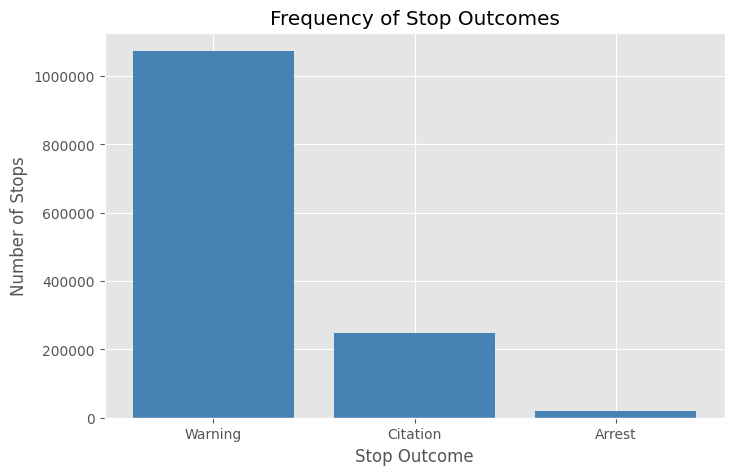

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# load datasets

DATA_DIR = Path("../Files")
housing_df = pd.read_csv(DATA_DIR / "df_housing_clean.csv")
main_df = pd.read_csv(DATA_DIR / "df_with_dummy_final.csv")
# clean files for EDA
# housing data

housing_df = housing_df.dropna(subset=["sale_price", "lat", "lng", "sale_date"])
housing_df = housing_df[housing_df["sale_price"] > 0]
housing_df["year"] = pd.to_datetime(housing_df["sale_date"]).dt.year
housing_df["log_price"] = np.log10(housing_df["sale_price"])
# SOPP data

main_df = main_df.dropna(subset=["WealthIndex"])
main_df["log_wealth"] = np.log10(main_df["WealthIndex"])
# wealth distribution across nashville

plt.figure(figsize=(10,8))
hb = plt.hexbin(
    housing_df["lng"],
    housing_df["lat"],
    C=housing_df["log_price"],
    reduce_C_function=np.mean,
    gridsize=40,
    cmap="magma_r",
    mincnt=1
)

cb = plt.colorbar(hb)
cb.set_label("Log10 Sale Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Log-Scaled House Prices Across Nashville")
plt.show()
# sale price distribution by year

data_by_year = [
    housing_df[housing_df["year"] == 2013]["log_price"],
    housing_df[housing_df["year"] == 2014]["log_price"],
    housing_df[housing_df["year"] == 2015]["log_price"],
    housing_df[housing_df["year"] == 2016]["log_price"]
]

plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(10, 6))
vp = ax.violinplot(data_by_year, showmeans=False, showmedians=True)
for body in vp["bodies"]:
    body.set_facecolor("steelblue")
    body.set_edgecolor("steelblue")
    body.set_alpha(0.85)

vp["cmedians"].set_color("black")
vp["cbars"].set_color("steelblue")
vp["cmins"].set_color("steelblue")
vp["cmaxes"].set_color("steelblue")
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["2013", "2014", "2015", "2016"])
ax.set_title("Distribution of House Prices by Year", fontsize=18)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Log10 Sale Price", fontsize=14)
plt.tight_layout()
plt.show()
# distribution of wealth index at stop locations

plt.figure(figsize=(8, 5))
plt.hist(main_df["log_wealth"], bins=40, color="steelblue", edgecolor="black")
plt.title("Distribution of Wealth Index at Stop Locations")
plt.xlabel("Log10 Wealth Index")
plt.ylabel("Number of Stops")
plt.show()
# distribution of wealth index by stop outcome

plt.figure(figsize=(10, 6))
ax = main_df.boxplot(
    column="log_wealth",
    by="outcome_encd",
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", color="steelblue"),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue"),
    medianprops=dict(color="black")
)

plt.title("Stop Outcome vs Wealth Index")
plt.suptitle("")
plt.xlabel("Stop Outcome")
plt.ylabel("Log10 Wealth Index")
plt.grid(False)
plt.xticks(
    ticks=[1, 2, 3],
    labels=["Warning", "Citation", "Arrest"]
)

plt.show()
# frequency of stop outcomes
# count frequency of each outcome

outcome_counts = main_df["outcome_encd"].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(["Warning", "Citation", "Arrest"], outcome_counts.values, color="steelblue")
plt.xlabel("Stop Outcome")
plt.ylabel("Number of Stops")
plt.title("Frequency of Stop Outcomes")
# remove scientific notation

plt.ticklabel_format(style='plain', axis='y')
plt.show()